# Chapter 7 — Mixture Models

Notes on Chapter 7 of *Bayesian Analysis with Python* (3rd edition).

## Set-up

### Imports

In [1]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

import const

### Defaults

In [2]:
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(const.RANDOM_SEED)

### Constants

In [3]:
# Data file paths and other hardcoded values go here

## Load data

In [4]:
cs = pd.read_csv(const.CHEMICAL_SHIFTS_DATA_PATH)
# cs_exp = cs['exp']

## Notes

### The Dirichlet distribution

The Dirichlet is the multivariate generalisation of the Beta.
Where the Beta puts a distribution over a single probability $p \in [0, 1]$, the Dirichlet puts a distribution over a probability vector $\mathbf{x} = (x_1, \dots, x_K)$ that lives on the *simplex*: $x_i \ge 0$ and $\sum_i x_i = 1$.
It is therefore the natural prior for the mixing weights of a $K$-component mixture, or for any set of category probabilities.

It has a concentration parameter $\boldsymbol{\alpha} = (\alpha_1, \dots, \alpha_K)$ with each $\alpha_i > 0$, playing the same role as the Beta's $(\alpha, \beta)$:

\begin{align*}
\mathbf{x} &\sim \text{Dir}(\boldsymbol{\alpha}) \\
p(\mathbf{x}) &\propto \prod_{i=1}^{K} x_i^{\alpha_i - 1}
\end{align*}

The Beta is exactly the $K = 2$ case: $\text{Beta}(\alpha, \beta) = \text{Dir}(\alpha, \beta)$ once you identify $p$ with $(p, 1-p)$.

**Interpreting $\boldsymbol{\alpha}$:**

- The mean is $\mathbb{E}[x_i] = \alpha_i / \sum_j \alpha_j$ — the $\alpha_i$ act like relative "pseudo-counts", so their proportions set where the distribution is centred.
- Their *sum* $\alpha_0 = \sum_j \alpha_j$ controls concentration: large $\alpha_0$ concentrates mass tightly around the mean, small $\alpha_0$ spreads it toward the corners of the simplex.
- A symmetric $\boldsymbol{\alpha} = (\alpha, \dots, \alpha)$ is uniform over categories; $\alpha = 1$ is uniform over the whole simplex, $\alpha < 1$ favours sparse vectors (mass on a few components), $\alpha > 1$ favours balanced vectors.

**Conjugacy:** the Dirichlet is conjugate to the categorical/multinomial, mirroring Beta–Binomial.
Observing counts $\mathbf{n} = (n_1, \dots, n_K)$ updates the posterior to $\text{Dir}(\boldsymbol{\alpha} + \mathbf{n})$ — just add the observed counts to the prior pseudo-counts.
This is why it is the default prior for mixture weights in the models below.

### Chemical mixture

Visualise the data

[Text(0.5, 1.0, 'Distribution of experimental chemical shifts'),
 Text(0.5, 0, 'Experimental chemical shift (ppm)')]

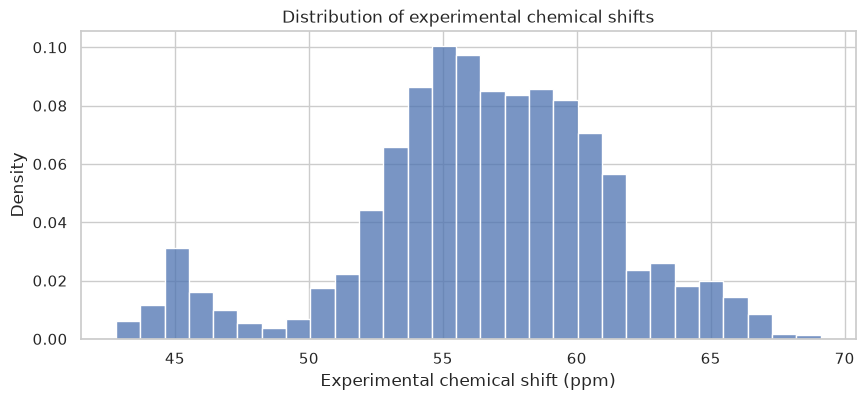

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(cs["exp"], stat="density", ax=ax)
ax.set(title="Distribution of experimental chemical shifts", xlabel="Experimental chemical shift (ppm)")

First the model that samples badly:

In [ ]:
K = 2
coords = {"component": range(K), "obs": range(len(cs["exp"]))}
with pm.Model(coords=coords) as model_kg:
    # data
    cs_exp = pm.Data("cs_exp", cs["exp"], dims="obs")
    cs_exp_mean = cs_exp.mean()

    # priors
    p = pm.Dirichlet('p', a=np.ones(K), dims="component")
    z = pm.Categorical('z', p=p, dims="obs")
    means = pm.Normal('means', mu=cs_exp_mean, sigma=10, dims="component")
    sd = pm.Exponential('sd', scale=5)

    # likelihood
    y = pm.Normal('y', mu=means[z], sigma=sd, observed=cs_exp, dims="obs")

    # sample
    idata_kg = pm.sample(draws=500, chains=4, random_seed=const.RANDOM_SEED)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>NUTS: [p, means, sd]
>BinaryGibbsMetropolis: [z]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 112 seconds.
/home/coder/bayesian-analysis-with-python/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [42]:
model_kg

cs_exp = Data(<shared>)
     p ~ Dirichlet(<constant>)
     z ~ Categorical(p)
 means ~ Normal(f(cs_exp), 10)
    sd ~ Exponential(5)
     y ~ Normal(f(means, z), sd)

Summary shows terrible `r_hat` and ESS (effective sample size)

In [46]:
pm.summary(idata_kg, var_names=["~z"], ci_prob=0.94, round_to=2)

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
means[0],52.16,5.31,46.20,57.63,2.95,16.70,1.83,3.74,0.22
means[1],52.14,5.33,46.16,57.62,2.95,17.44,1.83,3.75,0.21
p[0],0.50,0.41,0.08,0.92,2.94,17.80,1.83,0.29,0.01
p[1],0.50,0.41,0.08,0.92,2.94,17.80,1.83,0.29,0.01
sd,3.65,0.07,3.51,3.78,1256.94,1190.01,1.00,0.00,0.00


Trace plot confirms that the chains aren't mixing.

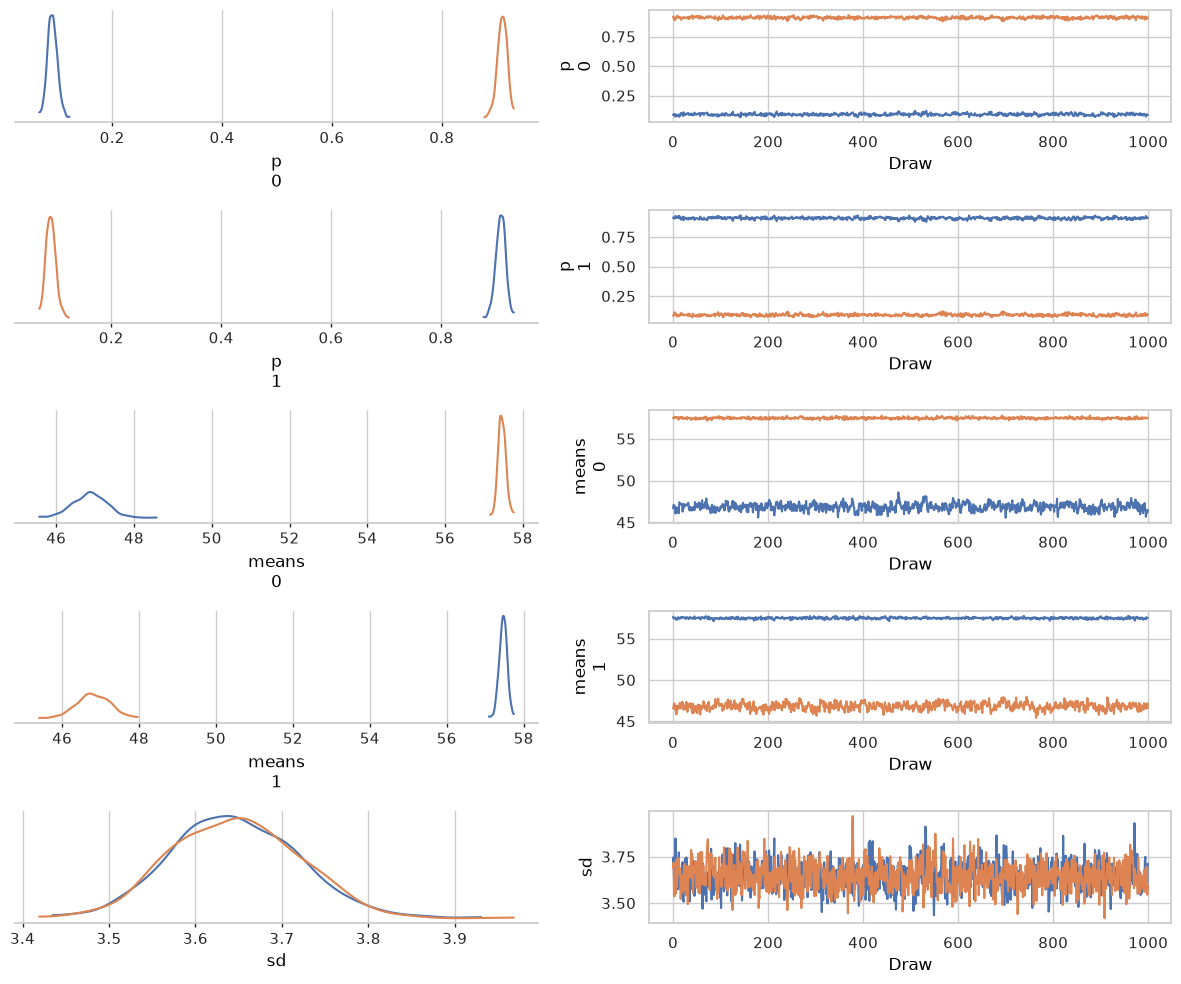

In [40]:
pc = az.plot_trace_dist(
    idata_kg,
    var_names=["p", "means", "sd"],
    compact=False,
    combined=False
)
fig = pc.viz["figure"].item()
fig.set_size_inches(12, 10)
fig.tight_layout()

We can improve the sampling with marginalisation.
Luckily PyMC can handle that with `NormalMixture`

In [45]:
K = 2
coords = {"component": range(K), "obs": range(len(cs["exp"]))}
with pm.Model(coords=coords) as model_mg:
    # data
    cs_exp = pm.Data("cs_exp", cs["exp"], dims="obs")
    cs_exp_mean = cs_exp.mean()

    # priors
    p = pm.Dirichlet('p', a=np.ones(K), dims="component")
    means = pm.Normal('means', mu=cs_exp_mean, sigma=10, dims="component")
    sd = pm.Exponential('sd', scale=5)

    # likelihood
    y = pm.NormalMixture('y', w=p, mu=means, sigma=sd, observed=cs_exp, dims="obs")

    # sample
    idata_mg = pm.sample(draws=1000, chains=4, random_seed=const.RANDOM_SEED)

NUTS[nutpie]: [p, means, sd]


Output()

This runs a lot faster but the r_hat is still high

In [48]:
pm.summary(idata_mg, ci_prob=0.94, round_to=2)

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
means[0],54.82,4.60,46.36,57.64,7.23,10.78,1.53,2.29,1.33
means[1],49.49,4.62,46.07,57.58,7.17,10.66,1.53,2.29,1.32
p[0],0.71,0.35,0.08,0.92,7.20,11.04,1.53,0.18,0.10
p[1],0.29,0.35,0.08,0.92,7.20,11.04,1.53,0.18,0.10
sd,3.65,0.07,3.52,3.79,4851.68,3441.72,1.00,0.00,0.00


The chains still aren't mixing.

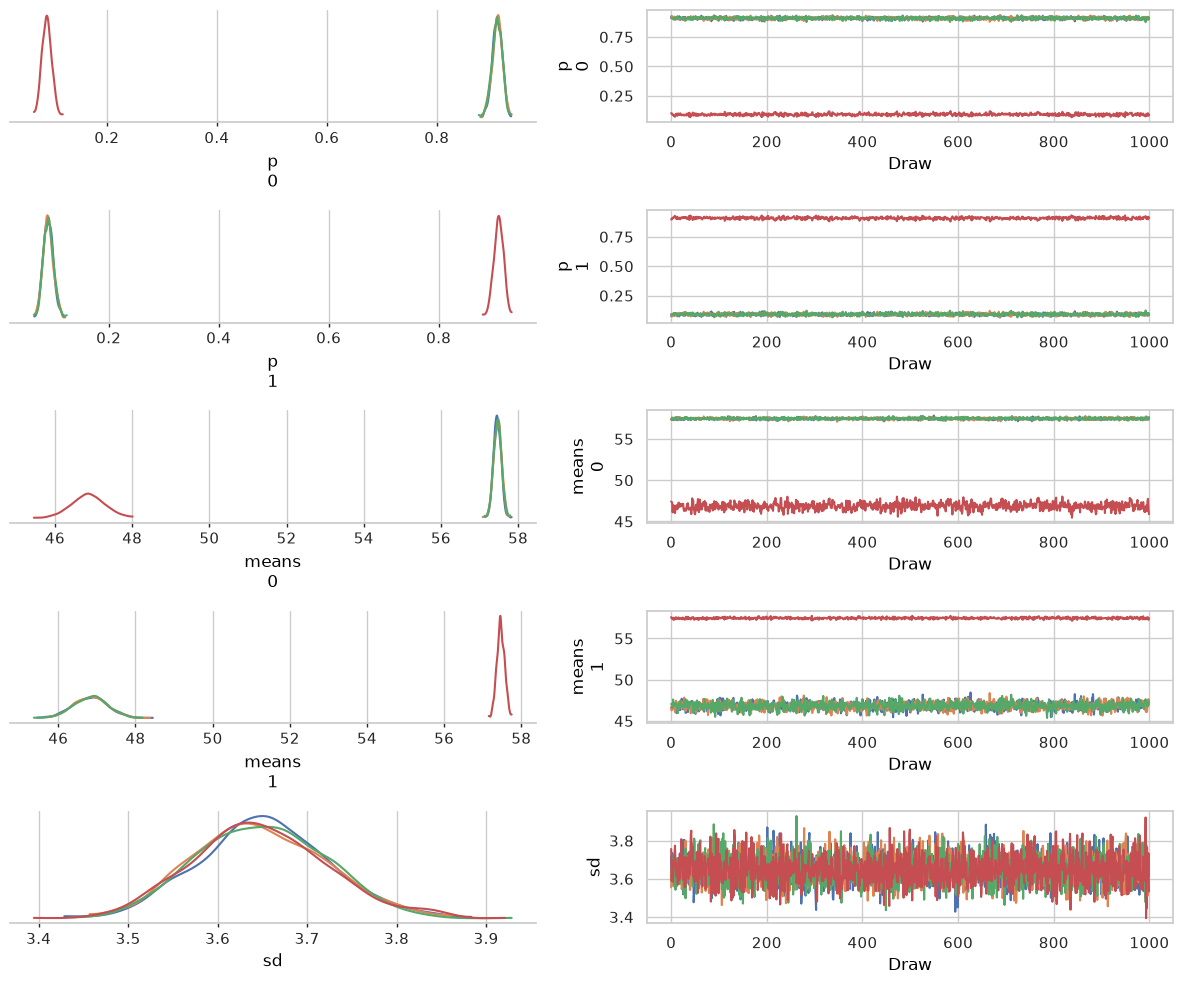

In [49]:
pc = az.plot_trace_dist(
    idata_mg,
    var_names=["p", "means", "sd"],
    compact=False,
    combined=False
)
fig = pc.viz["figure"].item()
fig.set_size_inches(12, 10)
fig.tight_layout()

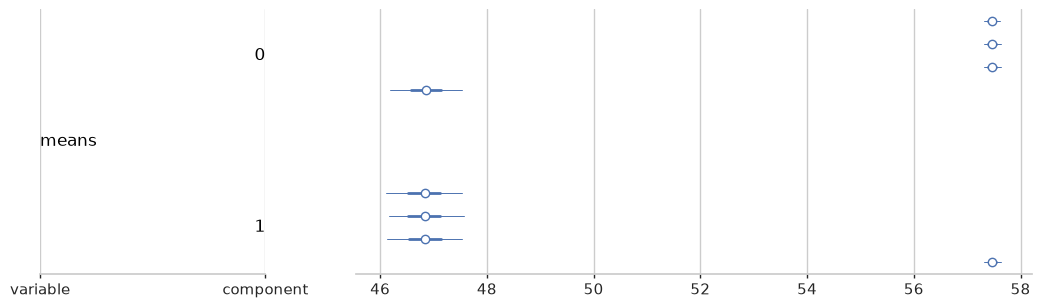

In [57]:
az.plot_forest(
    idata_mg,
    var_names=["means"]
);

This is because of non-identifiability in the model

### The non-identifiability of mixture models

We resolve the non-identifiability issue by forcing them to be ordered

In [71]:
K = 2
coords = {"component": range(K), "obs": range(len(cs["exp"]))}
with pm.Model(coords=coords) as model_mgo:
    # data
    cs_exp = pm.Data("cs_exp", cs["exp"], dims="obs")
    cs_exp_mean = cs_exp.mean()

    # priors
    p = pm.Dirichlet('p', a=np.ones(K), dims="component")
    means = pm.Normal('means', mu=cs_exp_mean, sigma=10, dims="component",
                      transform=pm.distributions.transforms.ordered,
                      initval=np.array([cs["exp"].mean()-1, cs["exp"].mean()+1]))
    sd = pm.Exponential('sd', lam=5)

    # likelihood
    y = pm.NormalMixture('y', w=p, mu=means, sigma=sd, observed=cs_exp, dims="obs")

    # sample
    idata_mgo = pm.sample(draws=1000, chains=4, random_seed=const.RANDOM_SEED)

NUTS[nutpie]: [p, means, sd]


Output()

Now it's all good

In [68]:
pm.summary(idata_mgo, ci_prob=0.94, round_to=2)

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p[0],0.09,0.01,0.07,0.11,2170.69,2139.28,1.0,0.00,0.00
p[1],0.91,0.01,0.89,0.93,2170.69,2139.28,1.0,0.00,0.00
means[0],46.83,0.44,46.02,47.67,644.56,837.07,1.0,0.02,0.01
means[1],57.47,0.10,57.29,57.65,4655.40,3088.62,1.0,0.00,0.00
sd,3.63,0.07,3.50,3.77,3164.67,2470.92,1.0,0.00,0.00


Chains are mixing

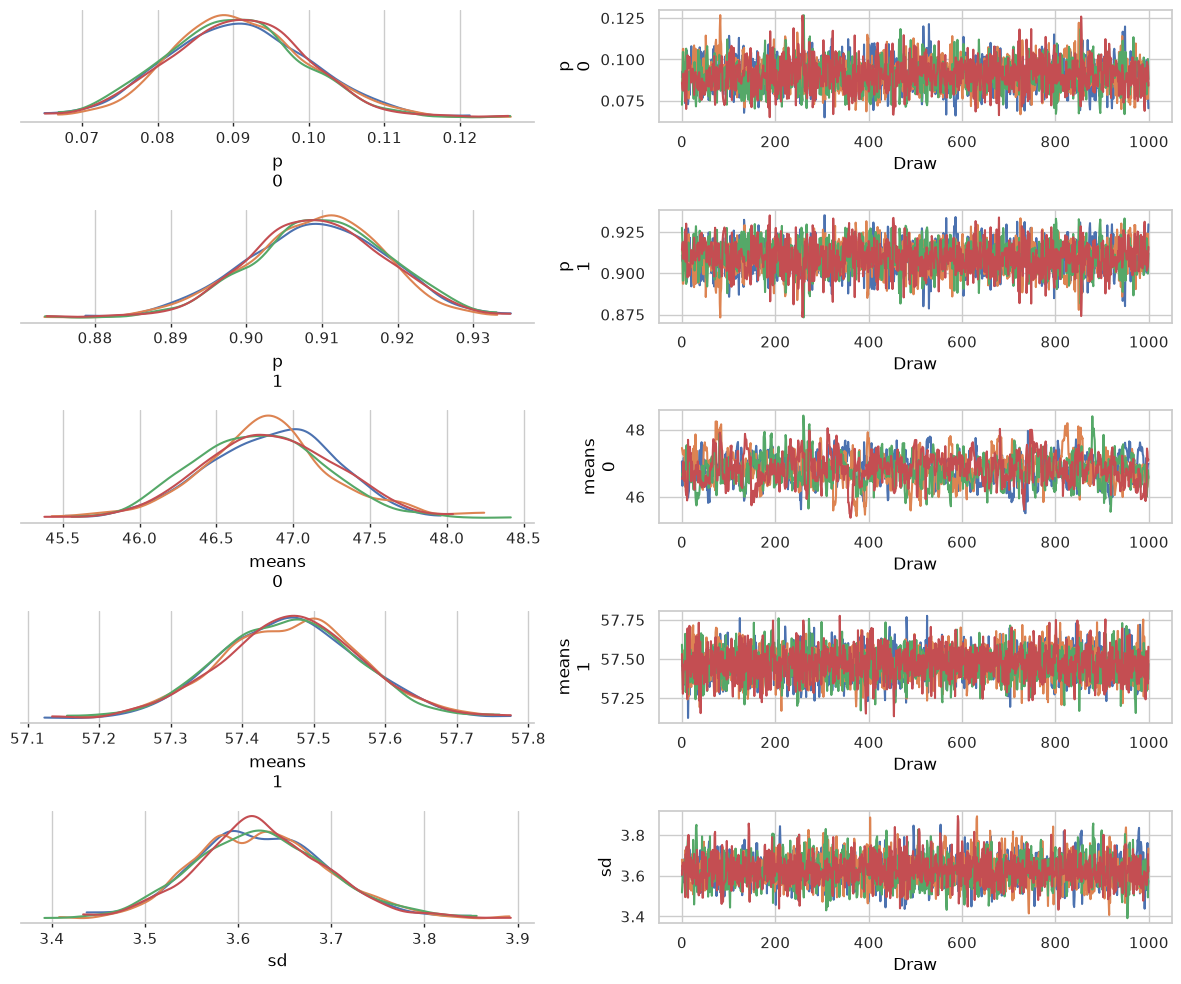

In [69]:
pc = az.plot_trace_dist(
    idata_mgo,
    var_names=["p", "means", "sd"],
    compact=False,
    combined=False
)
fig = pc.viz["figure"].item()
fig.set_size_inches(12, 10)
fig.tight_layout()

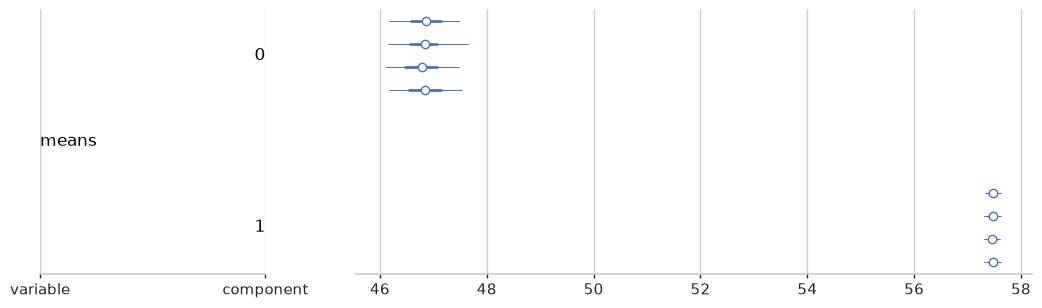

In [70]:
az.plot_forest(
    idata_mgo,
    var_names=["means"]
);